# 02 — Segmentación con K-Means

Objetivo:
- Correr K-Means sobre imágenes reales.
- Ver la segmentación reconstruida (imagen con solo K colores).
- Comparar cómo cambia al variar K.
- Comparar espacios de color (RGB vs HSV vs HSV circular).

### 1. Preparar el entorno

In [11]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src import config
from src import preprocessing as pp
from src import kmeans_segmentation as seg
from src import visualization as viz

# Cargar los pares imagen-máscara
pairs = pp.list_pairs(config.IMAGES_DIR, config.TRIMAPS_DIR)
print("Pares cargados:", len(pairs))

Pares cargados: 7390


### 2. Primera segmentación con K=2

Corremos K-Means sobre una imagen usando solo color RGB, con K=2 (la pregunta
principal: ¿separa animal de fondo?). Vemos la imagen original y la
reconstruida con solo 2 colores (el promedio de cada cluster).

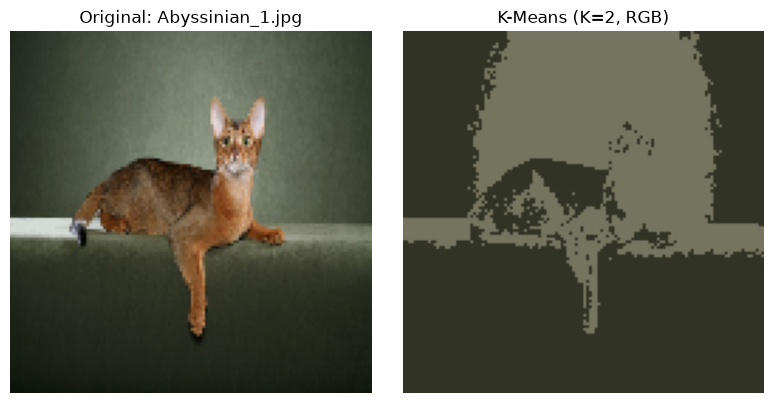

Inertia: 17569.85


In [12]:
# Elegimos una imagen de ejemplo
img_path, mask_path = pairs[0]
rgb = pp.load_image(img_path, resize_to=config.RESIZE_TO)

# Construir features RGB y correr K-Means con K=2
features = pp.build_features(rgb, space="rgb")
labels, model = seg.segment_image(
    features, config.RESIZE_TO, k=config.K_PRIMARY,
    random_state=config.RANDOM_STATE, n_init=config.N_INIT
)

# Reconstruir la imagen coloreada por cluster
segmentada = seg.labels_to_color(labels, rgb)

# Mostrar original vs segmentada
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rgb)
axes[0].set_title(f"Original: {img_path.name}")
axes[0].axis("off")
axes[1].imshow(segmentada)
axes[1].set_title(f"K-Means (K={config.K_PRIMARY}, RGB)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("Inertia:", round(model.inertia_, 2))

#### incluso en imágenes que parecen tener buen contraste, K-Means falla cuando el gatito comparte la paleta de color con el fondo, porque agrupa por color y no por objeto


### 3. Efecto de aumentar K

Con más clusters, K-Means tiene más divisiones disponibles. Vemos la misma
imagen segmentada con distintos valores de K para observar cómo cambia.

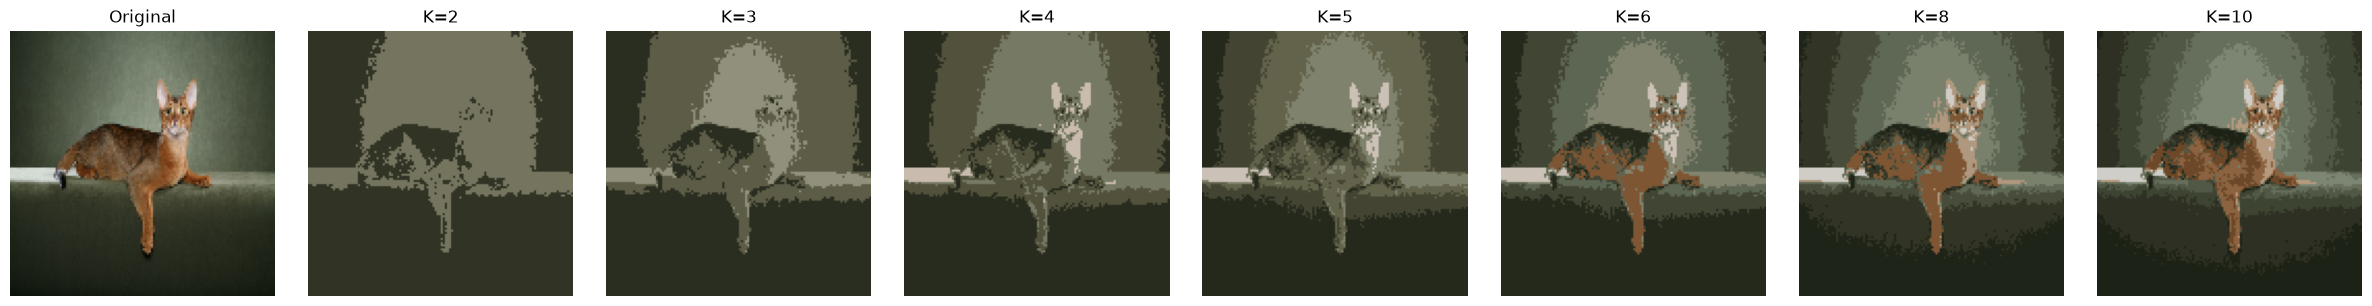

In [13]:
# Segmentar la misma imagen con distintos valores de K
segmentadas = []
for k in config.K_SWEEP:
    feats = pp.build_features(rgb, space="rgb")
    lbls, _ = seg.segment_image(
        feats, config.RESIZE_TO, k=k,
        random_state=config.RANDOM_STATE, n_init=config.N_INIT
    )
    segmentadas.append(seg.labels_to_color(lbls, rgb))

# Mostrar original + cada K en fila
viz.show_k_sweep(rgb, segmentadas, config.K_SWEEP)
plt.show()

#### subir K mejora la segmentación visual, pero ese mejor IoU refleja más capacidad de ajuste, no mejor comprensión del objeto

### 4. Comparar espacios de color

La misma imagen con K=2, pero usando distintas representaciones del color:
RGB, HSV crudo, y HSV circular ponderado por saturación. Queremos ver si
alguna separa mejor el animal del fondo.

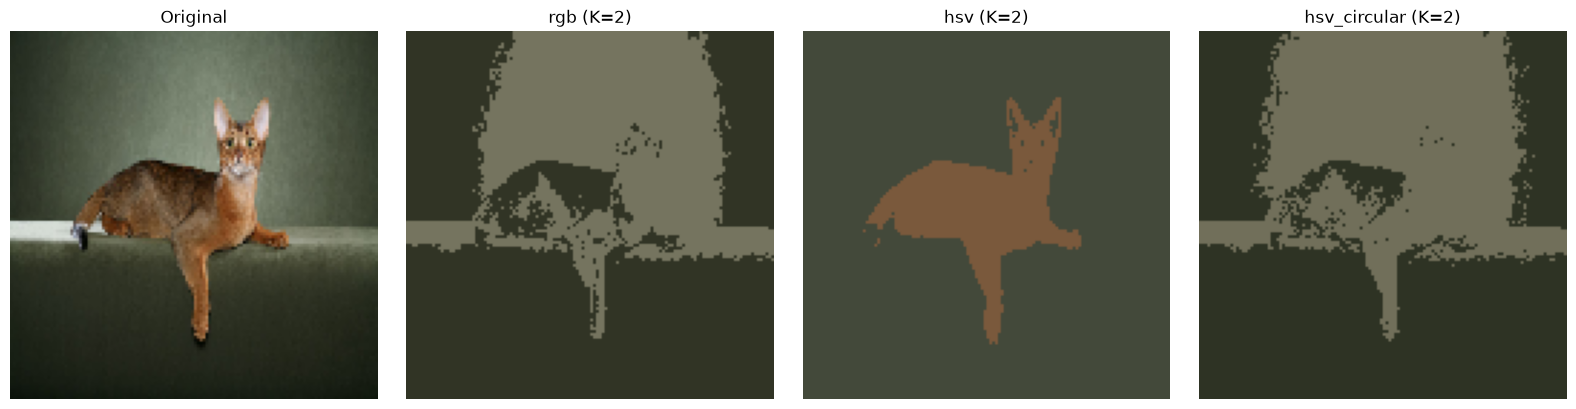

In [14]:
# Comparar espacios de color con K=2
espacios = ["rgb", "hsv", "hsv_circular"]
resultados = []

for espacio in espacios:
    feats = pp.build_features(rgb, space=espacio)
    lbls, _ = seg.segment_image(
        feats, config.RESIZE_TO, k=config.K_PRIMARY,
        random_state=config.RANDOM_STATE, n_init=config.N_INIT
    )
    resultados.append(seg.labels_to_color(lbls, rgb))

# Mostrar original + cada espacio
fig, axes = plt.subplots(1, len(espacios) + 1, figsize=(4 * (len(espacios) + 1), 4))
axes[0].imshow(rgb)
axes[0].set_title("Original")
axes[0].axis("off")
for ax, espacio, res in zip(axes[1:], espacios, resultados):
    ax.imshow(res)
    ax.set_title(f"{espacio} (K=2)")
    ax.axis("off")
plt.tight_layout()
plt.show()

#### HSV superó a RGB en imágenes donde el minino y el fondo difieren en matiz pero no en brillo. El HSV circular ponderado no fue uniformemente mejor, lo que sugiere que la ponderación por saturación ayuda en unos casos y quita señal en otros.